# Práctica de Aprendizaje No Supervisado - Mall Customers

**Estudiantes:**
- Luis Ernesto Jaldin Merida
- Jhaddyn Brian Ortiz Alanoca <br>

**Dataset:** Mall_Customers.csv  
**Objetivo:** Segmentar clientes según su edad, ingreso anual y puntuación de gasto.


## Paso 2 — Exploración de datos (EDA)

### 2.1 Cargar el dataset y mostrar las primeras filas

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Cargar dataset
df = pd.read_csv('/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 2.2 Ejecutar .info() y .describe()

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [22]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### 2.3 Identificar filas, columnas, nulos y rangos

El dataset tiene:
- **200 filas y 5 columnas**.  
- No hay valores nulos.
- Las variables numericas (`Age`, `Annual Income (k$)`, `Spending Score (1-100)`) tienen rangos:  
  - Edad: 18 – 70 años  
  - Ingreso anual: 15 – 137 (miles de dólares k$)  
  - Puntuacion de gasto: 1 – 99

### 2.4 Graficos exploratorios

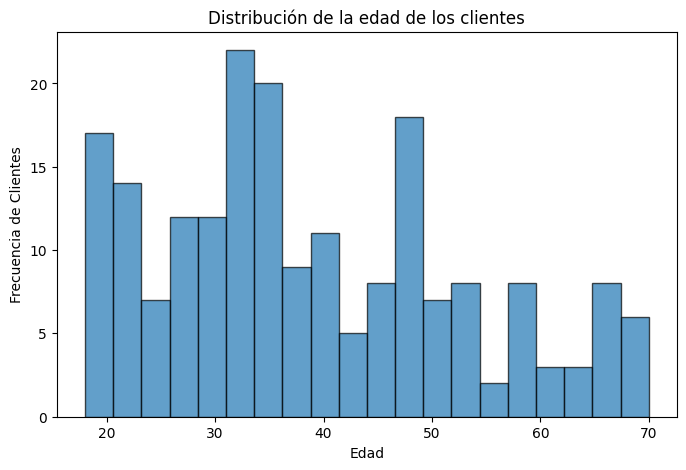

In [23]:
# Histograma de Age
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Edad')
plt.ylabel('Frecuencia de Clientes')
plt.title('Distribución de la edad de los clientes')
plt.show()

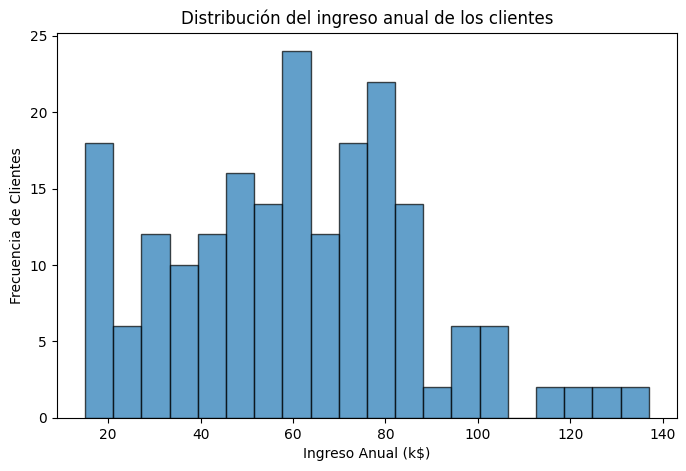

In [24]:
# Histograma de Annual Income
plt.figure(figsize=(8, 5))
plt.hist(df['Annual Income (k$)'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Ingreso Anual (k$)')
plt.ylabel('Frecuencia de Clientes')
plt.title('Distribución del ingreso anual de los clientes')
plt.show()

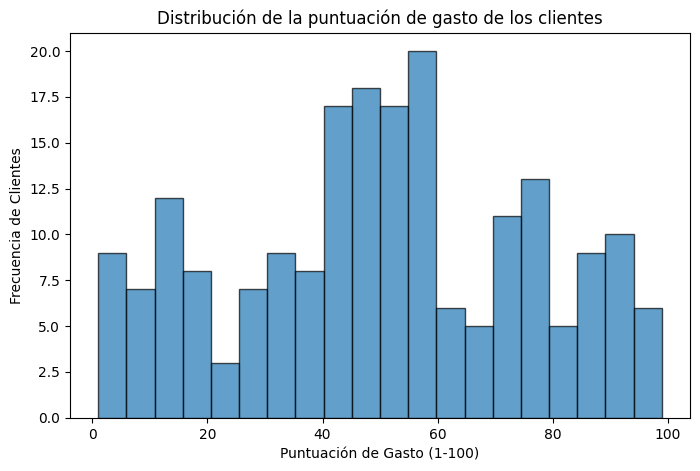

In [25]:
# Histograma de Spending Score
plt.figure(figsize=(8, 5))
plt.hist(df['Spending Score (1-100)'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Puntuación de Gasto (1-100)')
plt.ylabel('Frecuencia de Clientes')
plt.title('Distribución de la puntuación de gasto de los clientes')
plt.show()

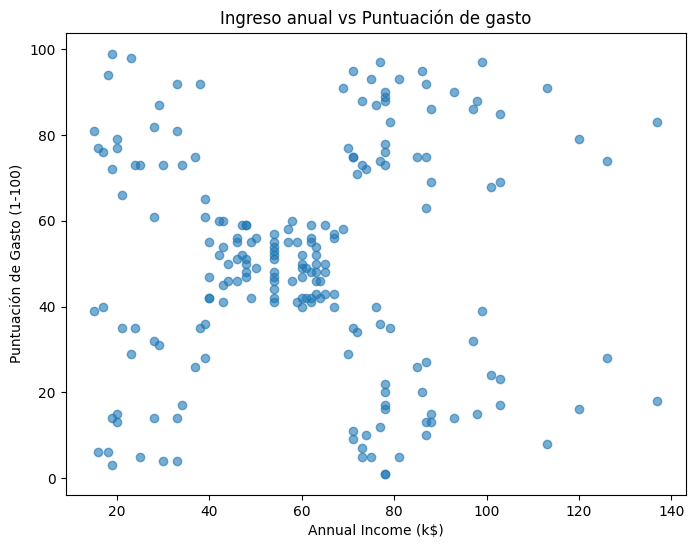

In [26]:
# Scatter plots entre ingresos y gasto
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], alpha=0.6)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.title('Ingreso anual vs Puntuación de gasto')
plt.show()

### Justificación del Paso 2

**Pregunta 1:** ¿Qué observas en tus gráficos? ¿Ya se nota a simple vista alguna agrupación o los datos parecen "una sola nube"?

**Respuesta:** Los histogramas muestran que las variables tienen distribuciones diferentes. En el gráfico de dispersión de ingreso anual y gasto se observan agrupaciones de clientes, aunque no están completamente separadas, lo que indica que existen posibles clusters.

## Paso 3 — Seleccion de variables y escalado

### 3.1 Elegir variables numericas para clusterizar

Seleccionamos las tres variables numericas: `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.  
Descartamos `CustomerID` y `Gender` porque no son relevantes para la segmentacion numerica.

In [27]:
# Variables para clusterizar
cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[cols]

# Verificar Rangos con describe()
print('Age:')
print(df['Age'].describe())
print('\nAnnual Income (k$):')
print(df['Annual Income (k$)'].describe())
print('\nSpending Score (1-100):')
print(df['Spending Score (1-100)'].describe())

Age:
count    200.000000
mean      38.850000
std       13.969007
min       18.000000
25%       28.750000
50%       36.000000
75%       49.000000
max       70.000000
Name: Age, dtype: float64

Annual Income (k$):
count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: Annual Income (k$), dtype: float64

Spending Score (1-100):
count    200.000000
mean      50.200000
std       25.823522
min        1.000000
25%       34.750000
50%       50.000000
75%       73.000000
max       99.000000
Name: Spending Score (1-100), dtype: float64


### 3.2 Aplicar StandardScaler

In [28]:
#Aplicando StandarScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Justificación del Paso 3

**Pregunta 1:** ¿Por qué elegiste esas variables y no otras del dataset?

**Respuesta:** Se utilizaron `Age`, `Annual Income` `Spending Score` y  porque describen el perfil de los clientes. `CustomerID` se descartó por ser un identificador y `Gender` no se utilizó en este análisis.

**Pregunta 2:** Mirando los rangos del Paso anterior, ¿por qué es necesario escalar en tu caso particular?

**Respuesta:** Los rangos son muy diferentes: edad (18-70), ingreso (15-137) y gasto (1-99). Sin escalar, el ingreso dominaría las distancias en K-Means y DBSCAN, haciendo que las otras variables tuvieran poco peso.

## Paso 4 — K-Means con varios valores de k

### 4.1 Entrenar K-Means para k de 2 a 8 y calcular inercia

### 4.2 Calcular silhouette score para cada k

### 4.3 Graficar la curva del codo y silhouette

In [29]:
inercia = []
silhouette = []
K_range = range(2, 9)

# Entrenar K-Means para k de 2 a 8 y calcular inercia
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)
    # Calcular silhouette score para cada k
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

# Mostrar valores
for k, iner, sil in zip(K_range, inercia, silhouette):
    print(f"k={k}: inercia={iner:.1f}, silhouette={sil:.3f}")

k=2: inercia=389.4, silhouette=0.335
k=3: inercia=295.2, silhouette=0.358
k=4: inercia=205.2, silhouette=0.404
k=5: inercia=168.2, silhouette=0.417
k=6: inercia=133.9, silhouette=0.428
k=7: inercia=117.0, silhouette=0.417
k=8: inercia=103.9, silhouette=0.408


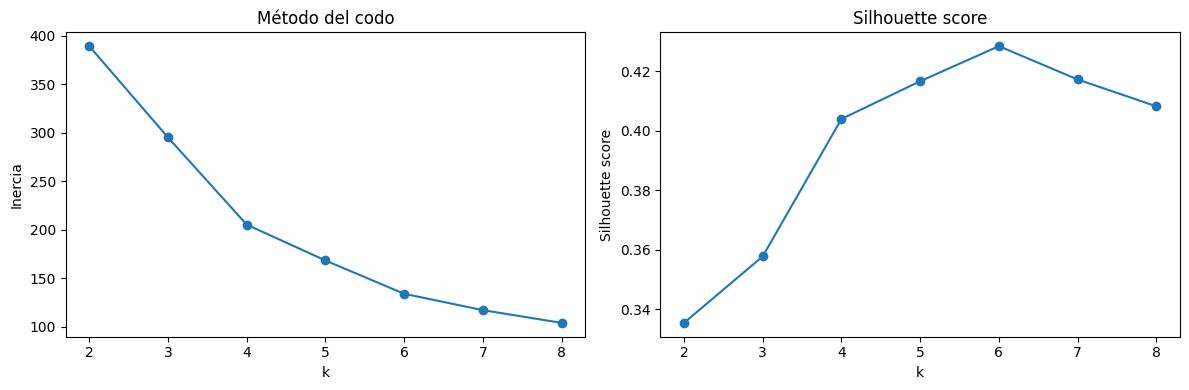

In [30]:
# Gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

#Metodo del codo
ax1.plot(K_range, inercia, marker='o')
ax1.set_xlabel('k')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del codo')

#Silhouette score
ax2.plot(K_range, silhouette, marker='o')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score')

plt.tight_layout()
plt.show()

### 4.4 Elegir k final

**Decisión:** Se eligió k = 5 porque el método del codo muestra un cambio claro en ese punto. Aunque el mayor Silhouette Score se obtiene con k = 6, la diferencia es pequeña y k = 5 ofrece una segmentación más simple.

### Justificación del Paso 4

**Pregunta 1:** ¿Qué k elegiste y qué mostraron el codo y el silhouette score para justificar esa elección?

**Respuesta:** Se eligió k = 5 porque el método del codo muestra un cambio claro en ese punto. Aunque el mayor Silhouette Score se obtiene con k = 6, la diferencia es pequeña y k = 5 ofrece una segmentación más simple.

## Paso 5 — Clustering jerárquico (para contrastar)

### 5.1 Generar dendrograma con linkage (ward)

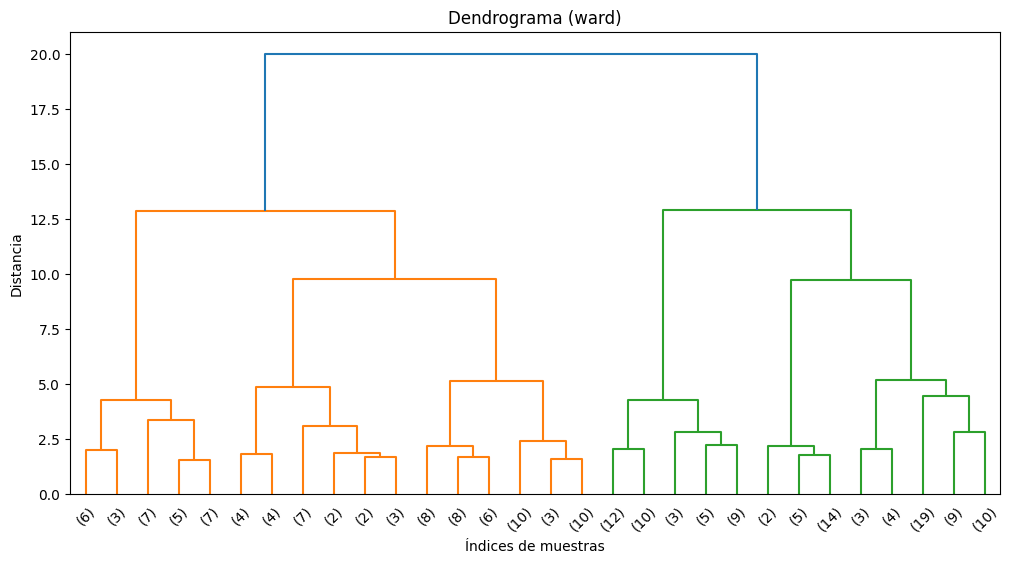

In [31]:
# Generar dendrograma con linkage (ward)
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Dendrograma (ward)')
plt.xlabel('Índices de muestras')
plt.ylabel('Distancia')
plt.show()

### 5.2 Cortar el árbol para obtener 5 clusters y comparar tamaños con K-Means

In [32]:
# Clustering jerárquico con 5 clusters
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
df['cluster_hc'] = hc.fit_predict(X_scaled)

# K-Means con 5 clusters
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans_5.fit_predict(X_scaled)

# Mostrar Tamaños
print("Tamaños de clusters (K-Means):")
print(df['cluster_kmeans'].value_counts().sort_index())
print("\nTamaños de clusters (Jerárquico):")
print(df['cluster_hc'].value_counts().sort_index())

Tamaños de clusters (K-Means):
cluster_kmeans
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

Tamaños de clusters (Jerárquico):
cluster_hc
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64


### Justificación del Paso 5

**Pregunta 1:** ¿Los grupos que forma el clustering jerárquico son parecidos a los de K-Means o muy distintos? ¿A qué crees que se debe eso?

**Respuesta:** K-Means (20, 54, 40, 39, 47) y el método jerárquico (66, 45, 39, 28, 22) generan grupos con tamaños diferentes. Esto indica que cada algoritmo segmenta los datos de manera distinta.

## Paso 6 — DBSCAN y detección de outliers

### 6.1 Probar combinaciones de eps y min_samples

Probamos eps = [0.3, 0.5, 0.7] y min_samples = [5, 10, 15] (para no alargar, mostraremos 3 combinaciones representativas).

In [33]:
# Combinaciones seleccionadas
params = [(0.3, 5), (0.5, 5), (0.7, 5)]
resultados = []

for eps, min_s in params:
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = np.sum(labels == -1)
    resultados.append((eps, min_s, n_clusters, n_outliers))
    print(f"eps={eps}, min_samples={min_s}: clusters={n_clusters}, outliers={n_outliers}")

    # Guardar para analisis posterior
    df[f'dbscan_{eps}_{min_s}'] = labels

eps=0.3, min_samples=5: clusters=10, outliers=134
eps=0.5, min_samples=5: clusters=6, outliers=60
eps=0.7, min_samples=5: clusters=1, outliers=14


**Pregunta 1:** ¿cuántos outliers detectó tu configuración final? Revisa esas filas específicas — ¿tiene sentido que sean atípicas dado lo que sabés del tema?

**Respuesta:** Con `eps=0.5` y `min_samples=5` se detectaron **60 outliers**. Estos representan clientes con características diferentes al resto.

## Paso 7 — Reducción de dimensionalidad y visualización

### 7.1 Aplicar PCA a 2 componentes sobre variables escaladas

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada por componente 1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"Varianza explicada por componente 2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum():.3f}")

Varianza explicada por componente 1: 0.443
Varianza explicada por componente 2: 0.333
Varianza total explicada: 0.776


### 7.2 Graficar clusters finales de K-Means en el espacio PCA

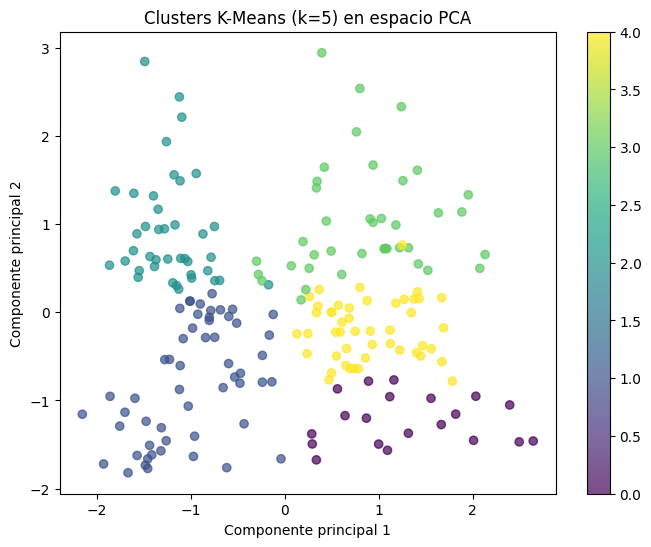

In [35]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_kmeans'], cmap='viridis', alpha=0.7)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Clusters K-Means (k=5) en espacio PCA')
plt.colorbar(scatter)
plt.show()

### Justificación del Paso 7

**Pregunta 1:** ¿Qué porcentaje de la información original conservan tus 2 componentes? Con ese dato, ¿confiarías en lo que se ve en el gráfico 2D, o te parece que se pierde demasiada información?

**Respuesta:** Las dos primeras componentes explican aproximadamente el 77.6% de la variabilidad de los datos. Esto permite visualizar los grupos conservando la mayor parte de la información.

## Paso 8 — Perfil de cada cluster y conclusiones

### 8.1 Calcular la media de cada variable original por cluster (K-Means)

In [36]:
perfil = df.groupby('cluster_kmeans')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
perfil

,Age,Annual Income (k$),Spending Score (1-100)
cluster_kmeans,,,
0,46.2,26.8,18.4
1,25.2,41.1,62.2
2,32.9,86.1,81.5
3,39.9,86.1,19.4
4,55.6,54.4,48.9


### 8.2 Nombrar cada cluster con una etiqueta descriptiva

- Cluster 0: Edad media 46, ingreso medio 27, gasto medio 18 → Clientes de bajo ingreso y bajo gasto.
- Cluster 1: Edad media 25, ingreso medio 41, gasto medio 62 → Jóvenes con ingreso medio y gasto alto.
- Cluster 2: Edad media 33, ingreso medio 86, gasto medio 82 → Clientes de alto ingreso y alto gasto.
- Cluster 3: Edad media 40, ingreso medio 86, gasto medio 19 → Clientes de alto ingreso y bajo gasto.
- Cluster 4: Edad media 56, ingreso medio 54, gasto medio 49 → Adultos mayores de ingreso medio y gasto medio.

Renombramos:

- Cluster 0: Bajo ingreso y bajo gasto.
- Cluster 1: Jóvenes de ingreso medio y gasto alto.
- Cluster 2: Alto ingreso y alto gasto.
- Cluster 3: Alto ingreso y bajo gasto.
- Cluster 4: Adultos mayores de ingreso medio y gasto medio.

### 8.3 Párrafo final de conclusiones

**Pregunta: ¿Qué caracteriza a cada cluster que encontraste?**  
**Respuesta:** Cada cluster presenta un perfil diferente: un grupo de bajo ingreso y bajo gasto, un grupo de jóvenes con ingreso medio y gasto alto, un grupo de alto ingreso y alto gasto, otro de alto ingreso y bajo gasto, y un grupo de adultos mayores con ingreso y gasto medios.

**Pregunta: ¿Los clusters que obtuviste coinciden con tu intuición inicial del Paso 1, o te sorprendió algo?**  
**Respuesta:** En general, los resultados coinciden con la idea de que existen grupos con distintos niveles de ingreso y gasto. Lo que más destaca es la presencia de un grupo de jóvenes con ingreso medio y gasto alto.

**Pregunta: Si tuvieras que usar estos clusters para una decisión real (una campaña, una intervención, una política), ¿qué acción propondrías para cada grupo?**  
**Respuesta:**
- Bajo ingreso y bajo gasto: ofrecer promociones y descuentos.
- Jóvenes de ingreso medio y gasto alto: programas de fidelización y beneficios exclusivos.
- Alto ingreso y alto gasto: promocionar productos o servicios premium.
- Alto ingreso y bajo gasto: diseñar campañas para incentivar las compras.
- Adultos mayores de ingreso y gasto medios: ofrecer productos y servicios adaptados a sus necesidades.

**¿Qué limitación tiene tu análisis? ¿Qué variable adicional te hubiera gustado tener?**
**Respuesta:**  
La principal limitación es que el análisis solo utiliza tres variables. Sería útil contar con información como la frecuencia de compra, el tipo de productos adquiridos o la antigüedad del cliente para obtener una segmentación más completa.